HistGradientBoosting Model Performance:
RMSE: 28.59
R² Score: 0.61
Cross-validated R²: 0.6364254145723598
Best parameters: {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 10, 'learning_rate': 0.05}
Best CV R²: 0.6644111283378262


C:\Users\HEDWIG\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


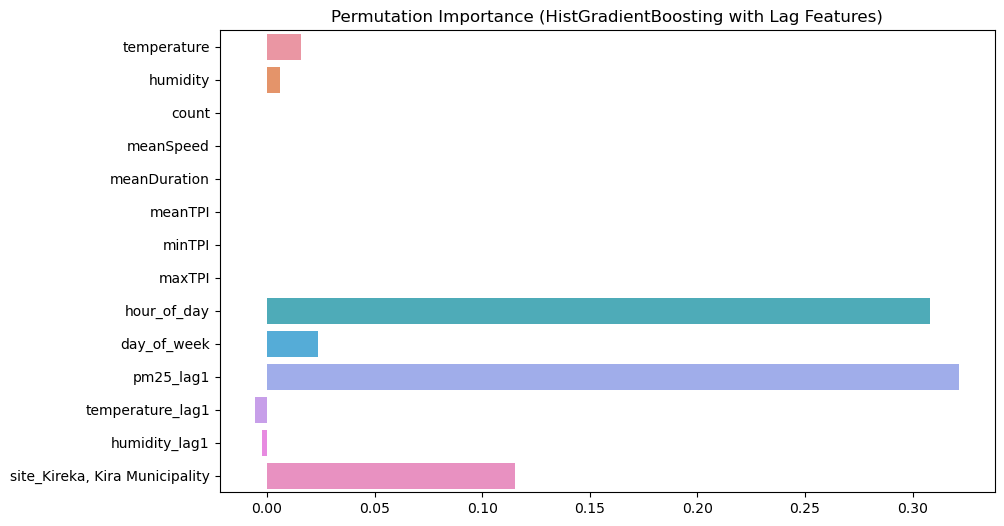

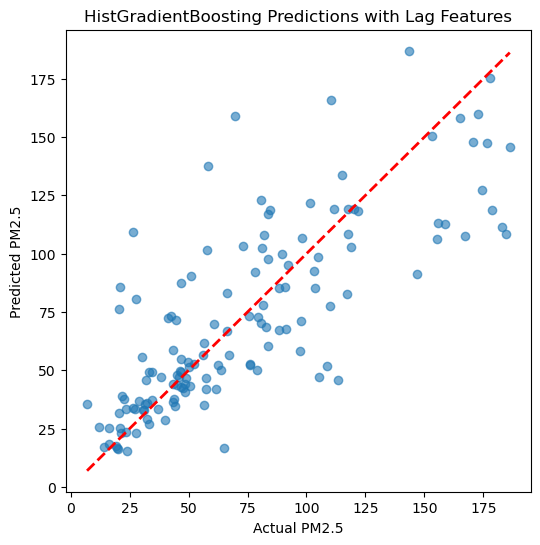

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load merged dataset
data = pd.read_json(r"E:\RSXS\Study\project\ParticulateMatterApp\data\ML\merged_record.json")

# 2. Add time features
data["hour_dt"] = pd.to_datetime(data["hour"])
data["hour_of_day"] = data["hour_dt"].dt.hour
data["day_of_week"] = data["hour_dt"].dt.dayofweek

# 3. Lag features (previous hour PM2.5, temperature, humidity)
data = data.sort_values("hour_dt")
data["pm25_lag1"] = data["pm25"].shift(1)
data["temperature_lag1"] = data["temperature"].shift(1)
data["humidity_lag1"] = data["humidity"].shift(1)

# 4. One-hot encode site
data = pd.get_dummies(data, columns=["site"], drop_first=True)

# 5. Define features and target
feature_cols = [
    "temperature", "humidity", "count", "meanSpeed", "meanDuration",
    "meanTPI", "minTPI", "maxTPI", "hour_of_day", "day_of_week",
    "pm25_lag1", "temperature_lag1", "humidity_lag1"
] + [col for col in data.columns if col.startswith("site_")]

X = data[feature_cols]
y = data["pm25"]

# Drop rows missing target or lag values
data = data.dropna(subset=["pm25", "pm25_lag1", "temperature_lag1", "humidity_lag1"])
X = X.loc[data.index]
y = y.loc[data.index]

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train HistGradientBoostingRegressor (baseline tuned model)
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.1,
    max_depth=10,
    random_state=42
)
hgb_model.fit(X_train, y_train)

# 8. Predictions
y_pred = hgb_model.predict(X_test)

# 9. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("HistGradientBoosting Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 10. Cross-validation (5-fold R²)
cv_scores = cross_val_score(hgb_model, X, y, cv=5, scoring="r2")
print("Cross-validated R²:", cv_scores.mean())

# 11. Hyperparameter tuning with RandomizedSearchCV
param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_iter": [200, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [10, 20, 30]
}

search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)

print("Best parameters:", search.best_params_)
print("Best CV R²:", search.best_score_)

# 12. Permutation importance
result = permutation_importance(hgb_model, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_cols)
plt.title("Permutation Importance (HistGradientBoosting with Lag Features)")
plt.show()

# 13. Scatter plot of predictions vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("HistGradientBoosting Predictions with Lag Features")
plt.show()
